## 1. Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("Coffee Shop Sales.xlsx")
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [3]:
df.isnull().sum()

,0
transaction_id,0
transaction_date,0
transaction_time,0
transaction_qty,0
store_id,0
store_location,0
product_id,0
unit_price,0
product_category,0
product_type,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [5]:
df['transaction_time'] = df['transaction_time'].astype(str)
df['transaction_time'] = pd.to_timedelta(df['transaction_time'])

In [6]:
df["total_sales"] = df["unit_price"] * df["transaction_qty"]
df["datetime"] = df['transaction_date'] + df['transaction_time']

In [7]:
df.describe()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,product_id,unit_price,total_sales,datetime
count,149116.000000,149116,149116,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000,149116
mean,74737.371872,2023-04-15 11:50:32.173609984,0 days 12:14:15.815794415,1.438276,5.342063,47.918607,3.382219,4.686367,2023-04-16 00:04:47.989404160
min,1.000000,2023-01-01 00:00:00,0 days 06:00:00,1.000000,3.000000,1.000000,0.800000,0.800000,2023-01-01 07:06:11
25%,37335.750000,2023-03-06 00:00:00,0 days 09:05:10.500000,1.000000,3.000000,33.000000,2.500000,3.000000,2023-03-06 13:37:08
50%,74727.500000,2023-04-24 00:00:00,0 days 11:15:28,1.000000,5.000000,47.000000,3.000000,3.750000,2023-04-24 08:24:32.500000
75%,112094.250000,2023-05-30 00:00:00,0 days 15:25:57,2.000000,8.000000,60.000000,3.750000,6.000000,2023-05-30 07:16:13
max,149456.000000,2023-06-30 00:00:00,0 days 20:59:32,8.000000,8.000000,87.000000,45.000000,360.000000,2023-06-30 20:57:19
std,43153.600016,NaN,0 days 03:45:57.901686173,0.542509,2.074241,17.930020,2.658723,4.227099,NaN


In [8]:
df_location = df.groupby("store_location").agg({
    "total_sales": "sum",
    "transaction_id": "count"
})
df_location

,total_sales,transaction_id
store_location,,
Astoria,232243.91,50599
Hell's Kitchen,236511.17,50735
Lower Manhattan,230057.25,47782


In [9]:
daily_sales_by_location = df.groupby(["transaction_date", "store_location"])["total_sales"].sum().unstack()
daily_sales_by_location

store_location,Astoria,Hell's Kitchen,Lower Manhattan
transaction_date,,,
2023-01-01,868.40,851.45,788.35
2023-01-02,925.50,828.80,649.05
2023-01-03,902.75,906.25,756.00
2023-01-04,808.25,781.65,630.20
2023-01-05,903.05,714.90,800.90
...,...,...,...
2023-06-26,1975.10,1746.10,2154.70
2023-06-27,1861.55,1676.70,2437.40
2023-06-28,1758.10,1445.85,1524.95


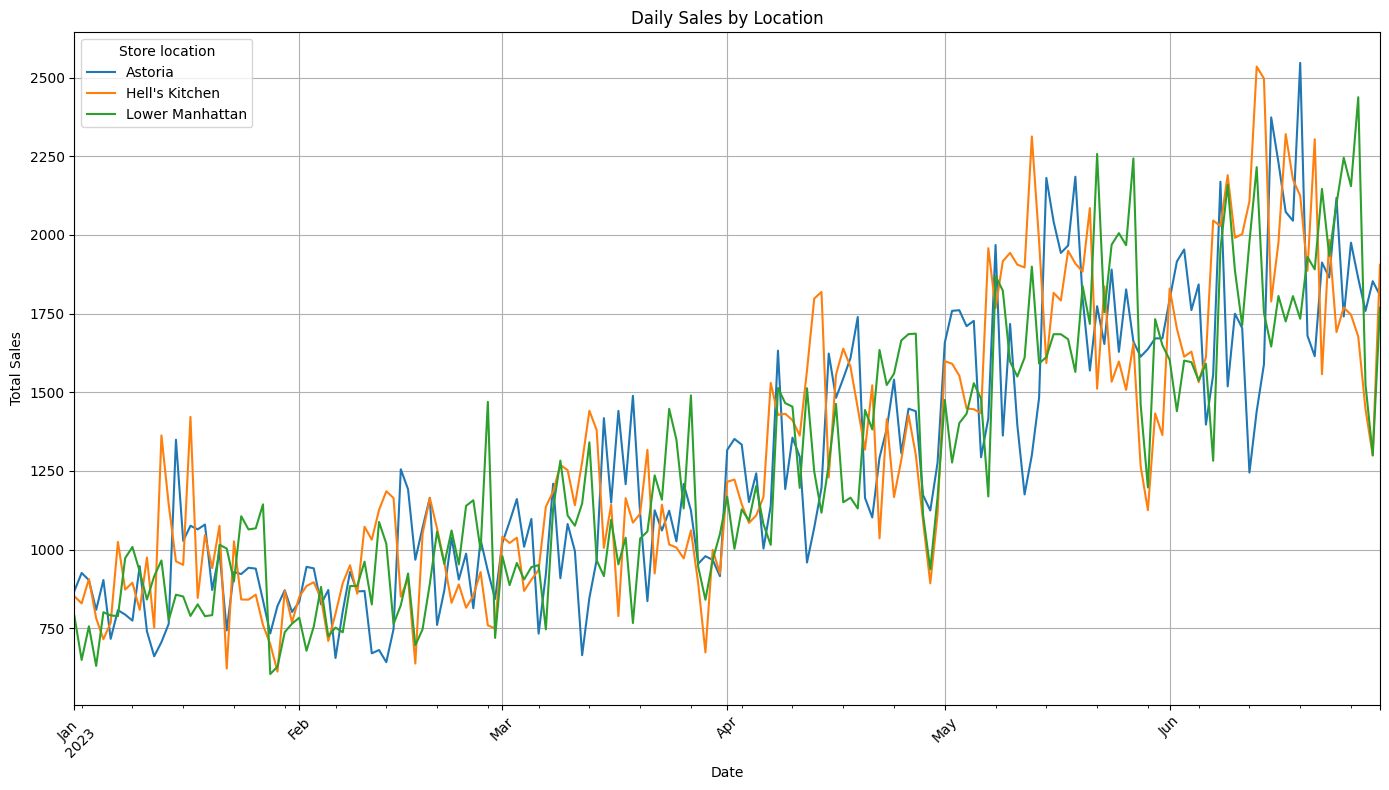

In [10]:
daily_sales_by_location.plot(figsize=(14,8), title = "Daily Sales by Location")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend(title = "Store location")
plt.grid(True)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [11]:
daily_sales_by_location.T

transaction_date,2023-01-01,2023-01-02,2023-01-03,2023-01-04,2023-01-05,2023-01-06,2023-01-07,2023-01-08,2023-01-09,2023-01-10,...,2023-06-21,2023-06-22,2023-06-23,2023-06-24,2023-06-25,2023-06-26,2023-06-27,2023-06-28,2023-06-29,2023-06-30
store_location,,,,,,,,,,,,,,,,,,,,,
Astoria,868.40,925.50,902.75,808.25,903.05,716.05,807.30,793.15,774.01,947.00,...,1614.25,1912.05,1864.40,2117.55,1740.70,1975.1,1861.55,1758.10,1852.75,1807.65
Hell's Kitchen,851.45,828.80,906.25,781.65,714.90,767.20,1024.10,872.83,894.40,808.10,...,2303.83,1557.10,1984.08,1690.80,1769.20,1746.1,1676.70,1445.85,1298.55,1904.93
Lower Manhattan,788.35,649.05,756.00,630.20,800.90,790.60,788.25,972.55,1008.20,930.55,...,1890.30,2145.95,1933.38,2097.75,2244.95,2154.7,2437.40,1524.95,1299.45,1768.74


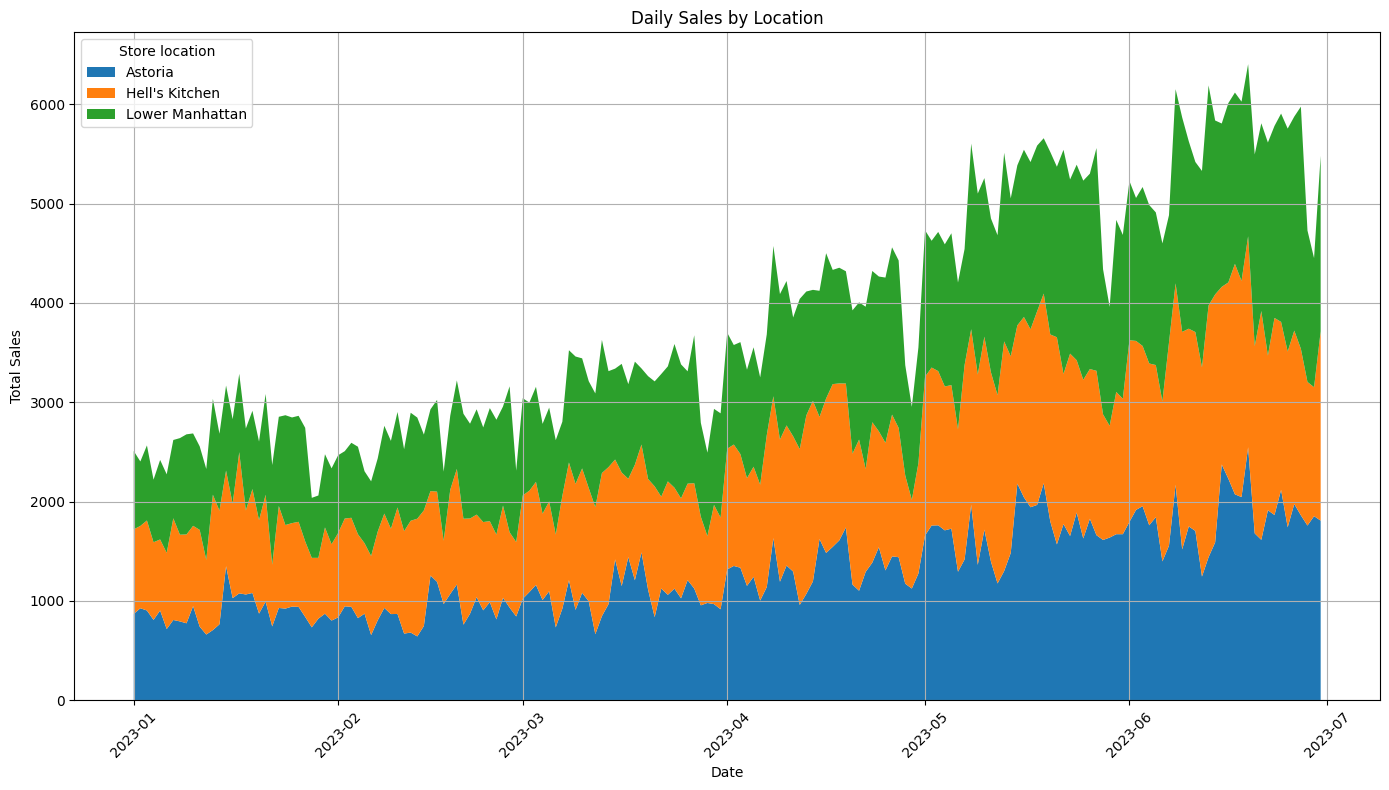

In [12]:
plt.figure(figsize = (14,8))
plt.stackplot(daily_sales_by_location.index, daily_sales_by_location.T, labels = daily_sales_by_location.columns)
plt.title("Daily Sales by Location")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend(title = "Store location", loc = "upper left")
plt.grid(True)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [13]:
daily_sales = df.groupby("transaction_date")["total_sales"].sum().reset_index()

df["day_of_the_week"] = df['datetime'].dt.day_name()
weekly_sales = df.groupby("day_of_the_week")["total_sales"].sum().reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]).reset_index()

df["month"] = df["datetime"].dt.to_period("M")
monthly_sales = df.groupby("month")["total_sales"].sum().reset_index()
daily_sales, weekly_sales, monthly_sales

(    transaction_date  total_sales
 0         2023-01-01      2508.20
 1         2023-01-02      2403.35
 2         2023-01-03      2565.00
 3         2023-01-04      2220.10
 4         2023-01-05      2418.85
 ..               ...          ...
 176       2023-06-26      5875.90
 177       2023-06-27      5975.65
 178       2023-06-28      4728.90
 179       2023-06-29      4450.75
 180       2023-06-30      5481.32
 
 [181 rows x 2 columns],
   day_of_the_week  total_sales
 0          Monday    101677.28
 1         Tuesday     99455.94
 2       Wednesday    100313.54
 3        Thursday    100767.78
 4          Friday    101373.00
 5        Saturday     96894.48
 6          Sunday     98330.31,
      month  total_sales
 0  2023-01     81677.74
 1  2023-02     76145.19
 2  2023-03     98834.68
 3  2023-04    118941.08
 4  2023-05    156727.76
 5  2023-06    166485.88)

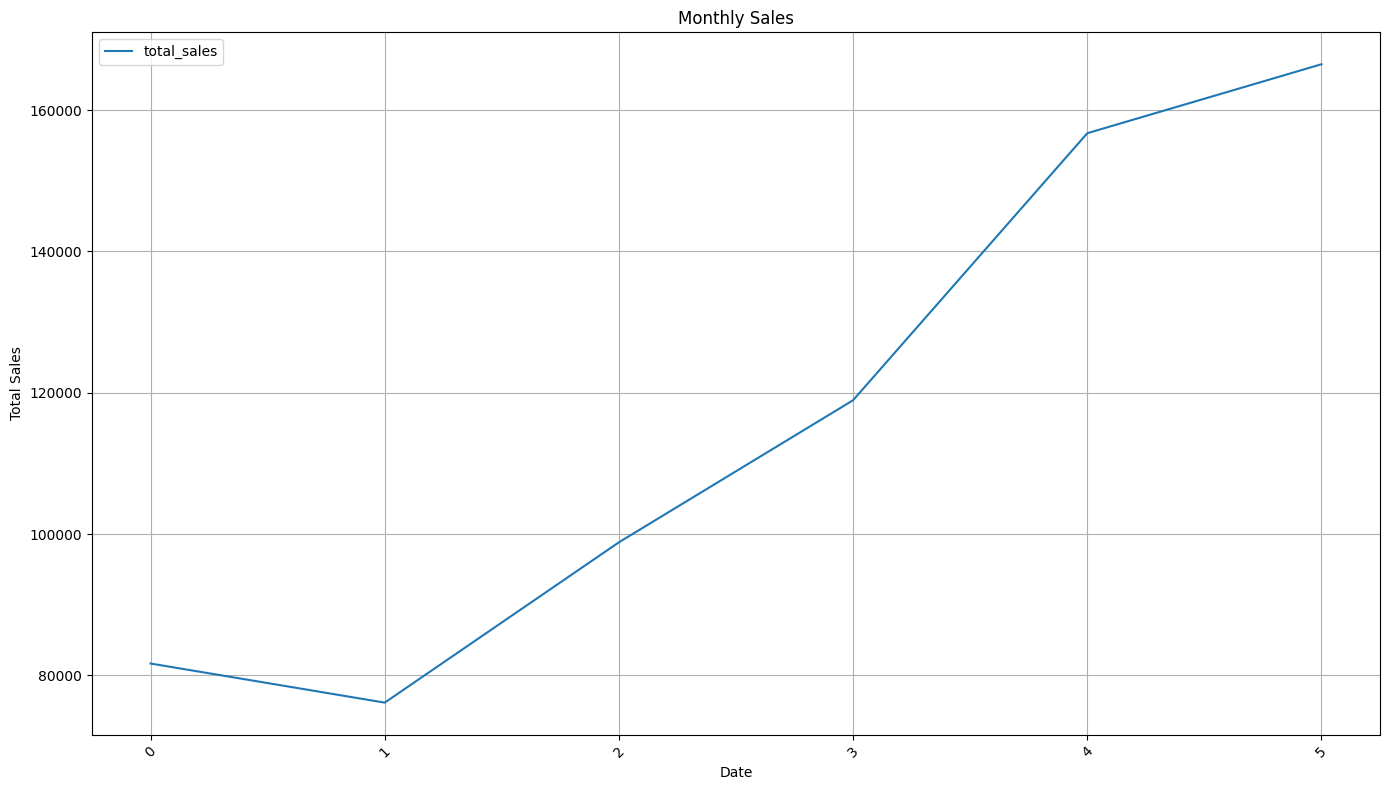

In [14]:
monthly_sales.plot(figsize=(14,8), title = "Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [15]:
weekly_sales = df.groupby(["day_of_the_week", "store_location" ])["total_sales"].sum().unstack().reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
weekly_sales

store_location,Astoria,Hell's Kitchen,Lower Manhattan
day_of_the_week,,,
Monday,33928.29,33389.51,34359.48
Tuesday,31816.76,34846.47,32792.71
Wednesday,34244.63,33779.09,32289.82
Thursday,34140.37,33468.06,33159.35
Friday,33472.75,34743.18,33157.07
Saturday,31845.93,32599.23,32449.32
Sunday,32795.18,33685.63,31849.50


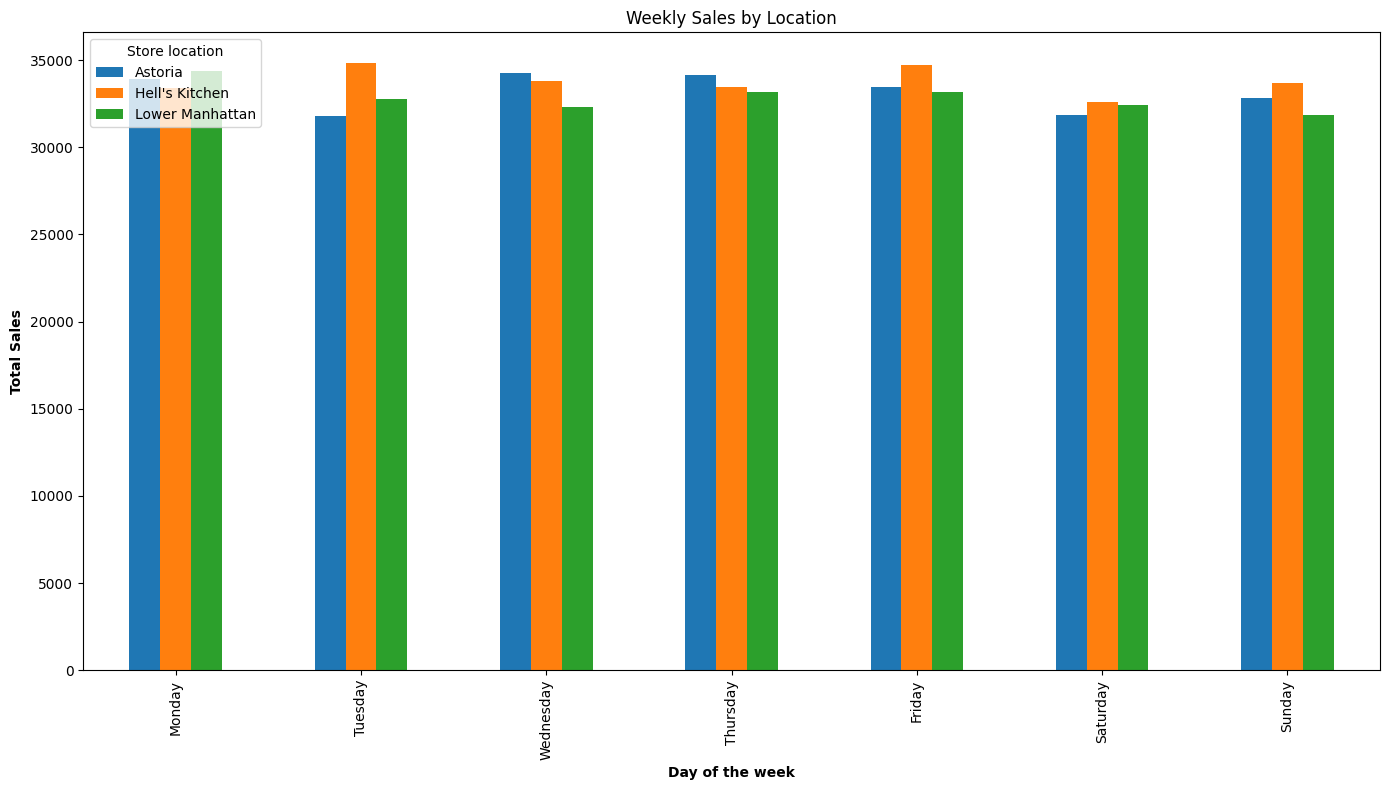

In [16]:
weekly_sales[["Astoria", "Hell's Kitchen", "Lower Manhattan"]].plot(kind = "bar", figsize = (14,8))
plt.xlabel("Day of the week", fontweight = "bold")
plt.ylabel("Total Sales", fontweight = "bold")
plt.title("Weekly Sales by Location")
plt.legend(title = "Store location", loc = "upper left")

plt.tight_layout()
plt.show()

In [17]:
df_category = df.groupby("product_category").agg({
    "total_sales": "sum",
    "transaction_id": "count"
}).sort_values("total_sales", ascending=False)
df_category

,total_sales,transaction_id
product_category,,
Coffee,269952.45,58416
Tea,196405.95,45449
Bakery,82315.64,22796
Drinking Chocolate,72416.00,11468
Coffee beans,40085.25,1753
Branded,13607.00,747
Loose Tea,11213.60,1210
Flavours,8408.80,6790
Packaged Chocolate,4407.64,487


In [18]:
df['hour'] = df["datetime"].dt.hour
product_hourly_sales = df.groupby(["hour", "product_category"])["total_sales"].sum().unstack()
product_hourly_sales

product_category,Bakery,Branded,Coffee,Coffee beans,Drinking Chocolate,Flavours,Loose Tea,Packaged Chocolate,Tea
hour,,,,,,,,,
6,2677.95,406.0,7811.95,874.45,2770.50,430.4,614.45,258.52,6056.05
7,7948.44,1754.0,23579.90,3602.20,6507.25,985.6,1229.05,680.18,17239.85
8,10417.84,2098.0,30579.85,5444.75,8166.00,1224.8,1403.85,605.78,22759.00
9,10523.91,2035.0,31014.85,7353.25,7787.50,1176.0,2072.15,383.82,22823.05
10,10982.50,1745.0,33297.10,7608.70,8070.50,1532.8,1608.45,799.79,23028.55
11,5612.06,532.0,18188.15,3295.20,4853.75,427.2,457.95,248.88,12703.95
12,4180.44,470.0,16162.90,1384.15,4416.50,333.6,476.50,101.60,12667.10
13,4421.08,966.0,16620.95,1566.65,4415.00,339.2,458.55,260.12,11319.90
14,4740.46,428.0,16725.35,1573.95,4637.50,356.8,471.30,238.88,12132.50


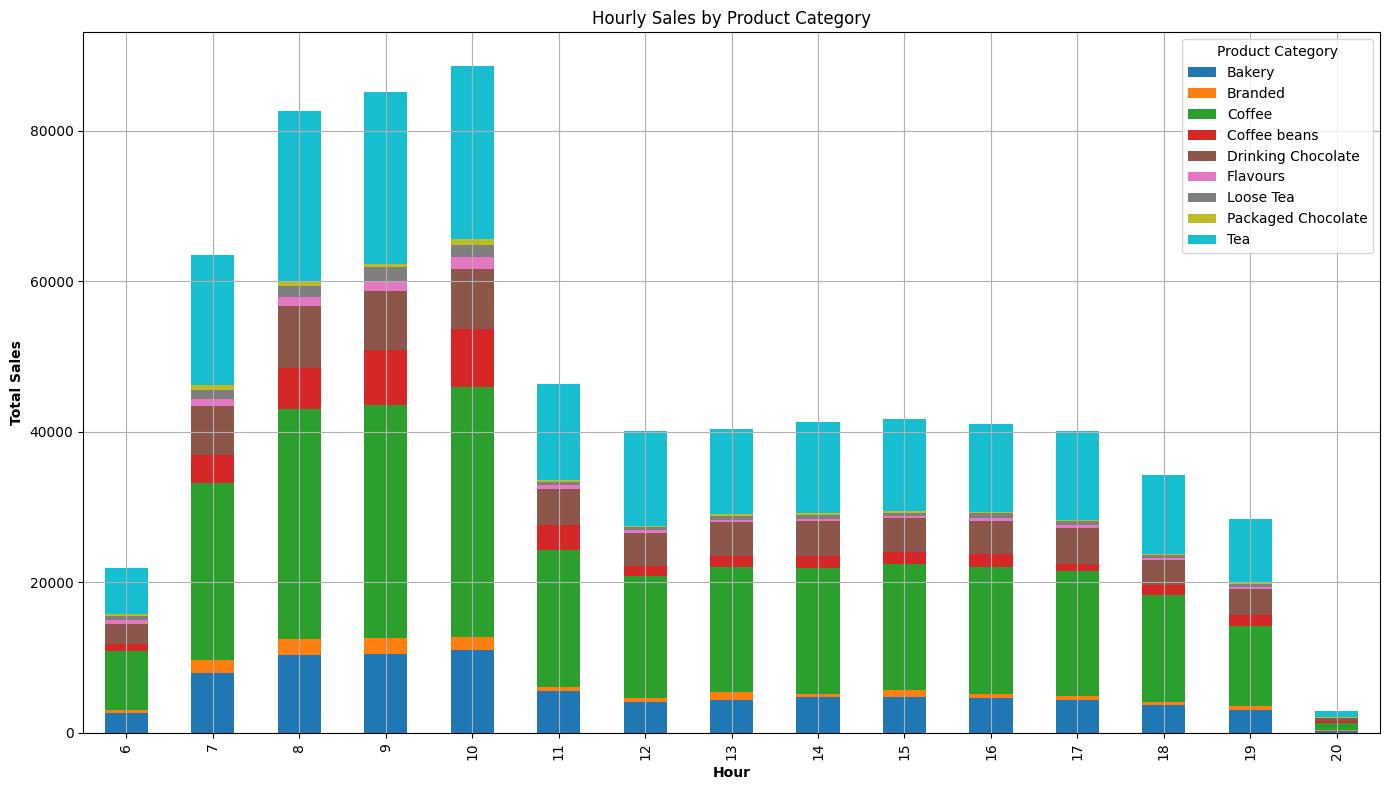

In [19]:
product_hourly_sales.plot(kind = "bar", stacked= True, figsize = (14,8), colormap="tab10")
plt.xlabel("Hour", fontweight = "bold")
plt.ylabel("Total Sales", fontweight = "bold")
plt.title("Hourly Sales by Product Category")
plt.legend(title = "Product Category")
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
df_category["average_sales"] = df_category["total_sales"] / df_category["transaction_id"]
df_category

,total_sales,transaction_id,average_sales
product_category,,,
Coffee,269952.45,58416,4.621207
Tea,196405.95,45449,4.321458
Bakery,82315.64,22796,3.610969
Drinking Chocolate,72416.00,11468,6.314615
Coffee beans,40085.25,1753,22.866657
Branded,13607.00,747,18.215529
Loose Tea,11213.60,1210,9.267438
Flavours,8408.80,6790,1.238409
Packaged Chocolate,4407.64,487,9.050595


In [21]:
sales_by_product = df.groupby("product_type").agg({
    "total_sales": "sum",
    "transaction_id": "count",
    "unit_price": "mean"
}).sort_values("total_sales", ascending=False)
sales_by_product

,total_sales,transaction_id,unit_price
product_type,,,
Barista Espresso,91406.20,16403,3.655200
Brewed Chai tea,77081.95,17183,2.936993
Hot chocolate,72416.00,11468,4.148827
Gourmet brewed coffee,70034.60,16912,2.696641
Brewed Black tea,47932.00,11350,2.744670
Brewed herbal tea,47539.50,11245,2.744731
Premium brewed coffee,38781.15,8135,3.122452
Organic brewed coffee,37746.50,8489,2.898021
Scone,36866.12,10173,3.534638


In [22]:
df[df["product_category"] == "Branded"]["product_type"].unique()

array(['Housewares', 'Clothing'], dtype=object)

In [23]:
product_sales_type = df.groupby(["product_category", "product_type"])["total_sales"].sum().reset_index()
product_sales_type

,product_category,product_type,total_sales
0,Bakery,Biscotti,19793.53
1,Bakery,Pastry,25655.99
2,Bakery,Scone,36866.12
3,Branded,Clothing,6163.00
4,Branded,Housewares,7444.00
5,Coffee,Barista Espresso,91406.20
6,Coffee,Drip coffee,31984.00
7,Coffee,Gourmet brewed coffee,70034.60
8,Coffee,Organic brewed coffee,37746.50
9,Coffee,Premium brewed coffee,38781.15


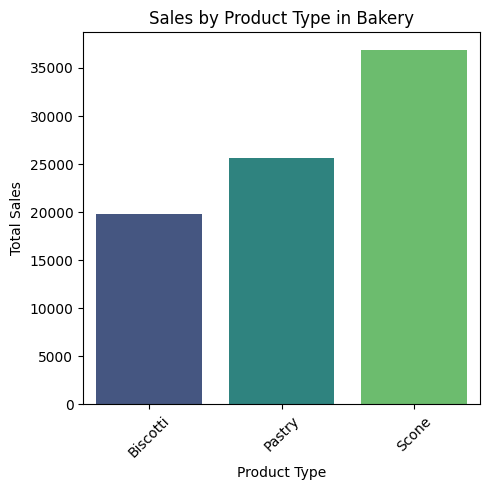

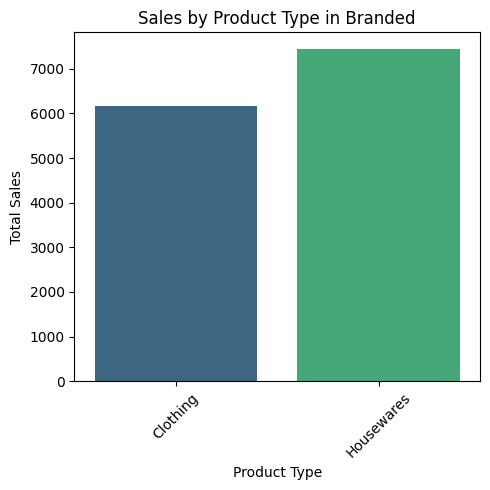

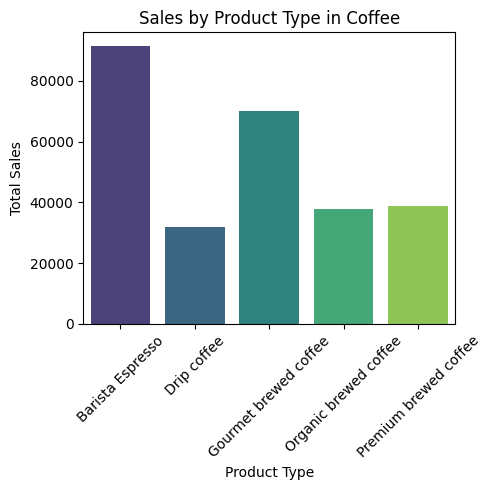

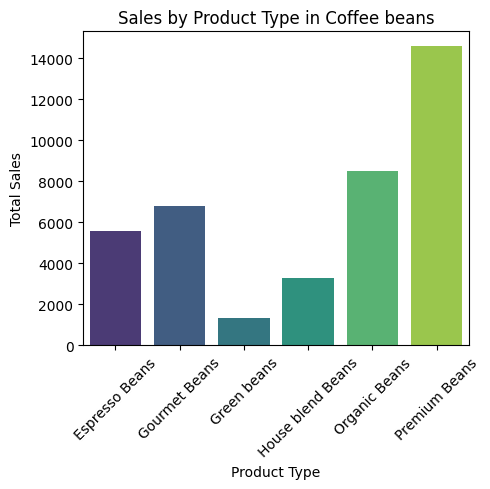

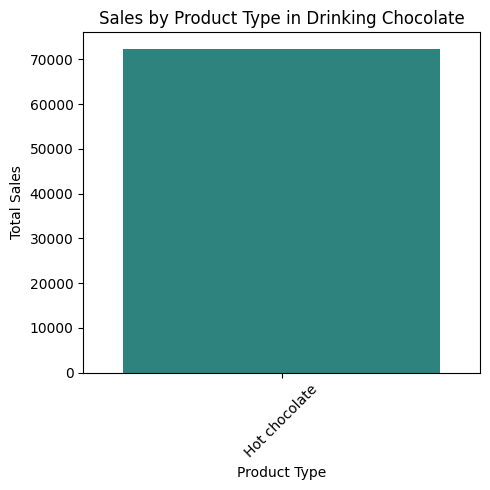

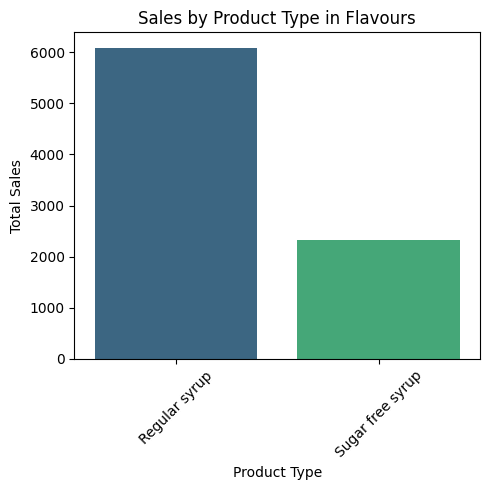

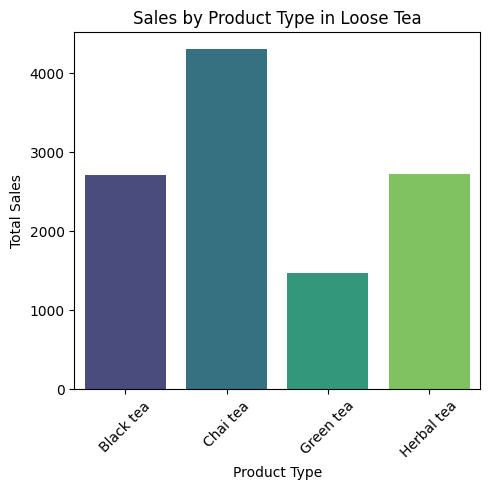

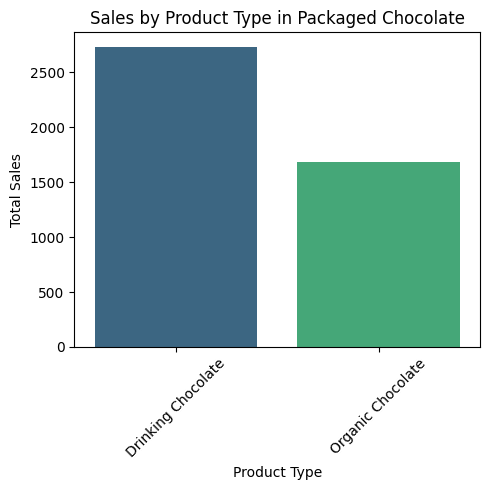

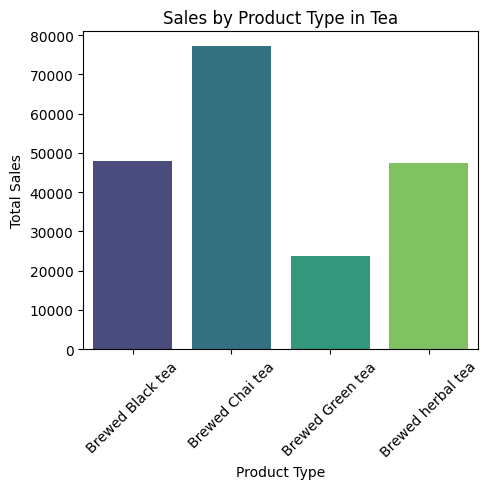

In [24]:
categories = product_sales_type["product_category"].unique()
for category in categories:
  plt.figure(figsize = (5,5))
  category_data = product_sales_type[product_sales_type["product_category"] == category]
  sns.barplot(data = category_data, x = "product_type", y = "total_sales", hue = "product_type", palette = "viridis", legend = False)
  plt.title(f"Sales by Product Type in {category}")
  plt.xlabel("Product Type")
  plt.ylabel("Total Sales")
  plt.xticks(rotation = 45)
  plt.tight_layout()
  plt.show()

In [25]:
hourly_sales_by_location = df.groupby(["hour", "store_location"])["total_sales"].sum().reset_index()
hourly_sales_by_location

,hour,store_location,total_sales
0,6,Hell's Kitchen,7531.17
1,6,Lower Manhattan,14369.10
2,7,Astoria,19028.80
3,7,Hell's Kitchen,15961.05
4,7,Lower Manhattan,28536.62
5,8,Astoria,22805.90
6,8,Hell's Kitchen,31544.44
7,8,Lower Manhattan,28349.53
8,9,Astoria,23183.57
9,9,Hell's Kitchen,32874.29


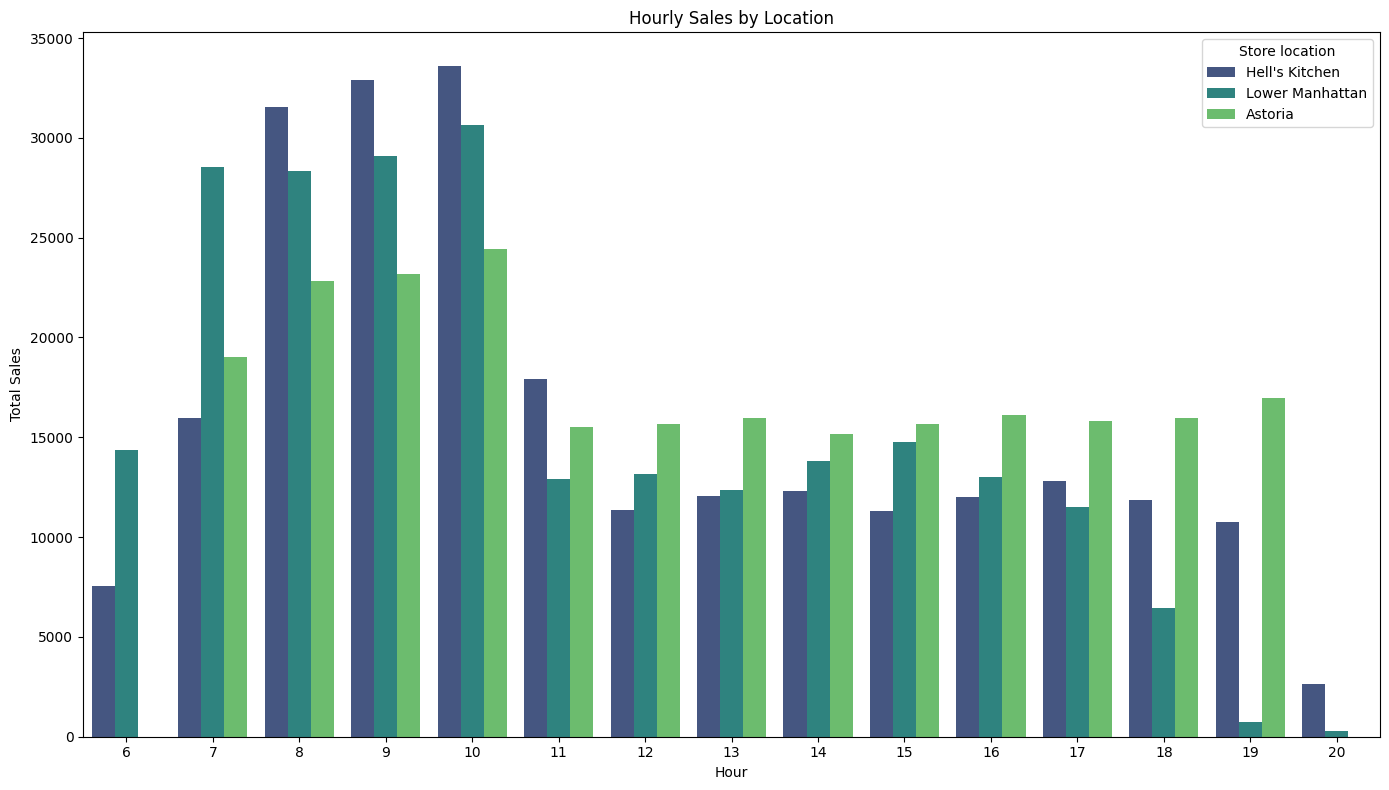

In [26]:
plt.figure(figsize = (14,8))
sns.barplot(data = hourly_sales_by_location, x = "hour", y = "total_sales", hue = "store_location", palette = "viridis")
plt.title("Hourly Sales by Location")
plt.xlabel("Hour")
plt.ylabel("Total Sales")
plt.legend(title = "Store location")
plt.tight_layout()
plt.show()